# 🏥 Fall Risk Prediction — ML Pipeline
**Stack:** XGBoost · SHAP · scikit-learn  
**Data:** Synthetic Synthea-style EHR (generated locally)  
**Sections:**
1. Setup & Imports
2. Data Generation / Loading
3. Exploratory Data Analysis (EDA)
4. Preprocessing
5. Model Training (XGBoost + Cross-Validation)
6. Evaluation
7. SHAP Explainability
8. Export Model & Artifacts

---
## 1 · Setup & Imports

In [2]:
# Install dependencies (run once; comment out after first run)
%pip install xgboost shap scikit-learn pandas numpy matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


In [4]:
import sys, subprocess, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay, average_precision_score,
    PrecisionRecallDisplay
)
import xgboost as xgb
import shap
import joblib

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Paths
DATA_DIR   = Path('data')
MODEL_DIR  = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

print(f"XGBoost  {xgb.__version__}")
print(f"SHAP     {shap.__version__}")
print(f"Python   {sys.version.split()[0]}")

XGBoost  3.3.0
SHAP     0.52.0
Python   3.12.13


---
## 2 · Data Generation / Loading

In [5]:
CSV_PATH = DATA_DIR / 'fall_risk_patients.csv'

if not CSV_PATH.exists():
    print('Generating synthetic dataset...')
    subprocess.run([sys.executable, str(DATA_DIR / 'generate_fall_risk_data.py'), '--n', '2000'], check=True)

df = pd.read_csv(CSV_PATH)
print(f'Loaded {len(df):,} patients, {df.columns.size} features')
df.head()

Loaded 2,000 patients, 22 features


,age,sex,bmi,has_parkinsons,has_osteoporosis,has_diabetes,has_dementia,has_depression,has_hypertension,on_sedatives,...,on_anticoagulants,systolic_bp,diastolic_bp,heart_rate,bun,sodium,hemoglobin,prior_fall,uses_assistive_device,fall_risk
0,24,F,21.9,0,0,0,0,0,1,0,...,0,130,92,90,40.0,139.3,10.9,0,0,0
1,78,M,32.5,0,0,0,1,0,1,0,...,0,129,87,89,17.2,141.6,17.8,0,0,0
2,69,M,20.9,0,0,0,1,1,0,0,...,0,107,77,59,20.4,138.3,14.1,0,0,0
3,52,M,25.9,0,0,0,0,1,0,0,...,0,146,75,73,20.6,137.8,13.1,0,1,0
4,51,F,24.3,0,0,0,0,0,0,0,...,0,107,72,80,23.2,134.2,17.8,0,0,0


---
## 3 · Exploratory Data Analysis

In [6]:
# Basic stats
print('Shape:', df.shape)
print('\nMissing values:', df.isnull().sum().sum())
print('\nTarget distribution:')
print(df['fall_risk'].value_counts(normalize=True).rename({0: 'No Fall (0)', 1: 'Fall (1)'})
      .map('{:.1%}'.format))

Shape: (2000, 22)

Missing values: 0

Target distribution:
fall_risk
No Fall (0)    77.1%
Fall (1)       22.9%
Name: proportion, dtype: str


In [7]:
df.describe().round(2)

,age,bmi,has_parkinsons,has_osteoporosis,has_diabetes,has_dementia,has_depression,has_hypertension,on_sedatives,on_diuretics,...,on_anticoagulants,systolic_bp,diastolic_bp,heart_rate,bun,sodium,hemoglobin,prior_fall,uses_assistive_device,fall_risk
count,2000.00,2000.00,2000.00,2000.00,2000.0,2000.00,2000.00,2000.00,2000.00,2000.00,...,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,56.49,27.63,0.06,0.22,0.2,0.08,0.14,0.34,0.13,0.24,...,0.12,130.43,82.67,75.68,18.30,138.00,13.46,0.29,0.22,0.23
std,22.63,5.44,0.23,0.42,0.4,0.28,0.35,0.47,0.33,0.43,...,0.33,18.03,12.21,14.03,7.69,4.01,1.95,0.46,0.41,0.42
min,18.00,15.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,...,0.00,80.00,50.00,40.00,5.00,121.00,7.00,0.00,0.00,0.00
25%,37.00,23.88,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,...,0.00,119.00,74.00,66.00,12.70,135.30,12.10,0.00,0.00,0.00
50%,57.00,27.60,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,...,0.00,131.00,83.00,76.00,18.20,137.90,13.50,0.00,0.00,0.00
75%,76.00,31.22,0.00,0.00,0.0,0.00,0.00,1.00,0.00,0.00,...,0.00,142.00,91.00,85.00,23.70,140.70,14.80,1.00,0.00,0.00
max,95.00,44.50,1.00,1.00,1.0,1.00,1.00,1.00,1.00,1.00,...,1.00,190.00,120.00,123.00,42.90,148.00,18.00,1.00,1.00,1.00


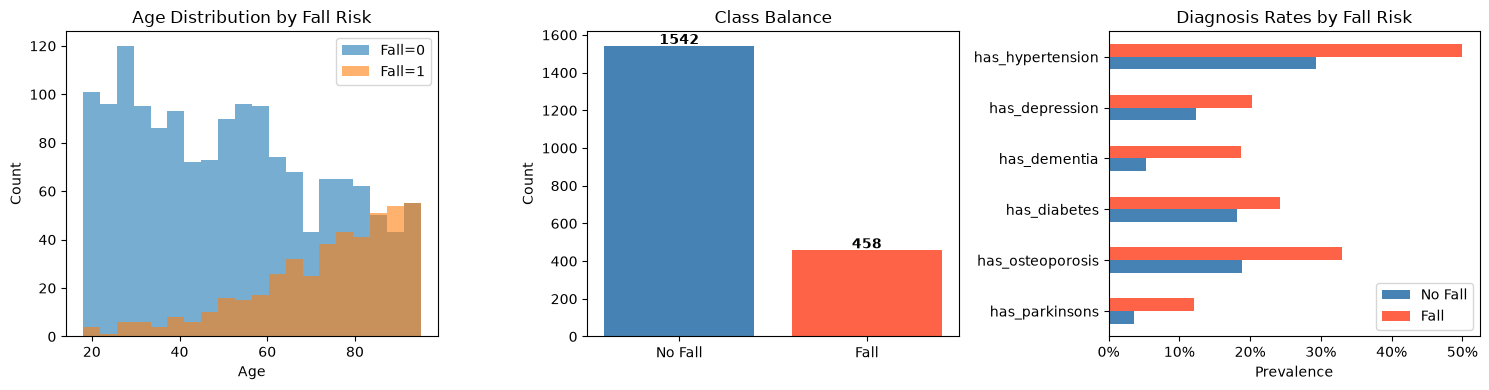

In [8]:
# ── Age distribution by fall risk ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age
for label, grp in df.groupby('fall_risk'):
    axes[0].hist(grp['age'], bins=20, alpha=0.6, label=f'Fall={label}')
axes[0].set(title='Age Distribution by Fall Risk', xlabel='Age', ylabel='Count')
axes[0].legend()

# Target balance
counts = df['fall_risk'].value_counts().sort_index()
axes[1].bar(['No Fall', 'Fall'], counts.values, color=['steelblue', 'tomato'])
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')
axes[1].set(title='Class Balance', ylabel='Count')

# Comorbidity rates by class
dx_cols = ['has_parkinsons','has_osteoporosis','has_diabetes','has_dementia',
           'has_depression','has_hypertension']
rates = df.groupby('fall_risk')[dx_cols].mean().T
rates.columns = ['No Fall', 'Fall']
rates.plot(kind='barh', ax=axes[2], color=['steelblue','tomato'])
axes[2].set(title='Diagnosis Rates by Fall Risk', xlabel='Prevalence')
axes[2].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.savefig(MODEL_DIR / 'eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()

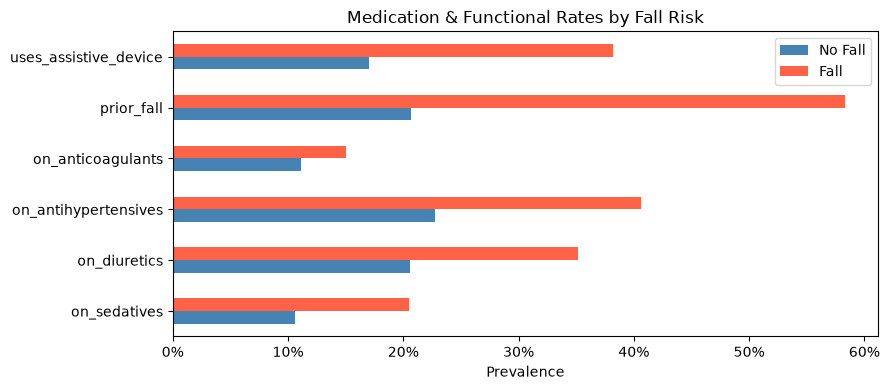

In [9]:
# ── Medication & functional risk factors ─────────────────────────────────────
risk_cols = ['on_sedatives','on_diuretics','on_antihypertensives','on_anticoagulants',
             'prior_fall','uses_assistive_device']
rates2 = df.groupby('fall_risk')[risk_cols].mean().T
rates2.columns = ['No Fall', 'Fall']

fig, ax = plt.subplots(figsize=(9, 4))
rates2.plot(kind='barh', ax=ax, color=['steelblue','tomato'])
ax.set(title='Medication & Functional Rates by Fall Risk', xlabel='Prevalence')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

In [ ]:
# ── Correlation heatmap (numeric features only) ──────────────────────────────
num_df = df.select_dtypes(include='number')
corr = num_df.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4 · Preprocessing

In [ ]:
TARGET = 'fall_risk'
CAT_FEATURES = ['sex']
NUM_FEATURES = [
    'age', 'bmi',
    'systolic_bp', 'diastolic_bp', 'heart_rate',
    'bun', 'sodium', 'hemoglobin'
]
BIN_FEATURES = [
    'has_parkinsons', 'has_osteoporosis', 'has_diabetes',
    'has_dementia', 'has_depression', 'has_hypertension',
    'on_sedatives', 'on_diuretics', 'on_antihypertensives', 'on_anticoagulants',
    'prior_fall', 'uses_assistive_device'
]
ALL_FEATURES = NUM_FEATURES + BIN_FEATURES + CAT_FEATURES

X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()

# Train / test split (stratified to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Fall prevalence — Train: {y_train.mean():.1%}  Test: {y_test.mean():.1%}')

In [ ]:
# ── Column transformer: scale numerics, one-hot encode sex ──────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUM_FEATURES),
        ('cat', OneHotEncoder(drop='if_binary', sparse_output=False), CAT_FEATURES),
        ('bin', 'passthrough', BIN_FEATURES),   # binary 0/1 need no scaling
    ],
    remainder='drop'
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Recover feature names after transformation
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(CAT_FEATURES).tolist()
feature_names = NUM_FEATURES + cat_names + BIN_FEATURES

print(f'Preprocessed shape: {X_train_proc.shape}  — {len(feature_names)} features')
print('Features:', feature_names)

---
## 5 · Model Training — XGBoost + Cross-Validation

In [ ]:
# Class imbalance: set scale_pos_weight = (neg / pos)
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pw  = neg / pos
print(f'scale_pos_weight = {scale_pw:.2f}  (neg={neg}, pos={pos})')

model = xgb.XGBClassifier(
    n_estimators       = 400,
    max_depth          = 5,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    min_child_weight   = 3,
    gamma              = 0.1,
    reg_lambda         = 1.5,
    scale_pos_weight   = scale_pw,
    eval_metric        = 'logloss',
    use_label_encoder  = False,
    random_state       = SEED,
    n_jobs             = -1
)

# 5-fold stratified CV on training data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(model, X_train_proc, y_train, cv=cv,
                             scoring='roc_auc', n_jobs=-1)

print(f'\n5-Fold CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Per-fold: {np.round(cv_scores, 4)}')

In [ ]:
# Final training on full train set with early stopping on a validation split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_proc, y_train, test_size=0.15, stratify=y_train, random_state=SEED
)

model.set_params(n_estimators=1000, early_stopping_rounds=30)
model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=100
)
print(f'\nBest iteration: {model.best_iteration}')

---
## 6 · Evaluation

In [ ]:
y_pred       = model.predict(X_test_proc)
y_pred_proba = model.predict_proba(X_test_proc)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc  = average_precision_score(y_test, y_pred_proba)

print(f'Test ROC-AUC : {roc_auc:.4f}')
print(f'Test PR-AUC  : {pr_auc:.4f}  (avg precision)\n')
print(classification_report(y_test, y_pred, target_names=['No Fall', 'Fall']))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['No Fall', 'Fall'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Confusion Matrix')

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1], color='steelblue')
axes[1].set_title(f'ROC Curve  (AUC = {roc_auc:.3f})')
axes[1].plot([0,1],[0,1],'k--', alpha=0.4)

# Precision-Recall curve
PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba, ax=axes[2], color='tomato')
axes[2].set_title(f'Precision-Recall  (AP = {pr_auc:.3f})')

plt.tight_layout()
plt.savefig(MODEL_DIR / 'evaluation_curves.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Risk score distribution ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
for label, color in [(0, 'steelblue'), (1, 'tomato')]:
    mask = y_test == label
    ax.hist(y_pred_proba[mask], bins=30, alpha=0.6,
            label=f'{"No Fall" if label==0 else "Fall"} (n={mask.sum()})',
            color=color, density=True)
ax.set(title='Predicted Probability Distribution', xlabel='Fall Risk Score', ylabel='Density')
ax.axvline(0.5, color='black', linestyle='--', alpha=0.6, label='Threshold 0.5')
ax.legend()
plt.tight_layout()
plt.show()

---
## 7 · SHAP Explainability

In [ ]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer(X_test_proc)

# Wrap in DataFrame with readable names for plots
shap_df = pd.DataFrame(shap_values.values, columns=feature_names)

print(f'SHAP values computed for {len(shap_df):,} test patients.')

In [ ]:
# ── Global: Beeswarm summary plot ────────────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values.values,
    pd.DataFrame(X_test_proc, columns=feature_names),
    max_display=20,
    show=False
)
plt.title('SHAP Summary — Global Feature Importance', fontsize=13)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Global: Mean |SHAP| bar chart ────────────────────────────────────────────
plt.figure(figsize=(9, 6))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title('Mean |SHAP| — Top 15 Features', fontsize=13)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'shap_bar.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Local: Waterfall plot for a high-risk patient ────────────────────────────
high_risk_idx = int(np.argmax(y_pred_proba))   # highest predicted risk

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[high_risk_idx], max_display=15, show=False)
plt.title(f'SHAP Waterfall — Patient #{high_risk_idx}  '
          f'(Risk Score: {y_pred_proba[high_risk_idx]:.2%})', fontsize=12)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'shap_waterfall_high_risk.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Local: Waterfall for a low-risk patient ───────────────────────────────────
low_risk_idx = int(np.argmin(y_pred_proba))

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[low_risk_idx], max_display=15, show=False)
plt.title(f'SHAP Waterfall — Patient #{low_risk_idx}  '
          f'(Risk Score: {y_pred_proba[low_risk_idx]:.2%})', fontsize=12)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'shap_waterfall_low_risk.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Dependence plot: age vs SHAP value, colored by prior_fall ────────────────
age_idx  = feature_names.index('age')
fall_idx = feature_names.index('prior_fall')

plt.figure(figsize=(8, 5))
shap.dependence_plot(
    age_idx,
    shap_values.values,
    pd.DataFrame(X_test_proc, columns=feature_names),
    interaction_index=fall_idx,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP Dependence: Age (colored by Prior Fall)', fontsize=12)
plt.tight_layout()
plt.show()

---
## 8 · Export Model & Artifacts

In [ ]:
# Save model
model.save_model(MODEL_DIR / 'fall_risk_xgb.json')   # portable XGBoost JSON
joblib.dump(model, MODEL_DIR / 'fall_risk_xgb.joblib')  # sklearn-compatible pkl

# Save preprocessor (needed for inference on raw patient data)
joblib.dump(preprocessor, MODEL_DIR / 'preprocessor.joblib')

# Save feature schema
import json
schema = {
    'feature_names'   : feature_names,
    'num_features'    : NUM_FEATURES,
    'bin_features'    : BIN_FEATURES,
    'cat_features'    : CAT_FEATURES,
    'target'          : TARGET,
    'xgb_best_iter'   : int(model.best_iteration),
    'test_roc_auc'    : round(roc_auc, 4),
    'test_pr_auc'     : round(pr_auc, 4),
}
(MODEL_DIR / 'model_schema.json').write_text(json.dumps(schema, indent=2))

print('Saved:')
for p in sorted(MODEL_DIR.iterdir()):
    print(f'  {p.name}  ({p.stat().st_size / 1024:.1f} KB)')

In [ ]:
# ── Quick inference smoke-test (mimics Streamlit flow) ───────────────────────
sample_patient = pd.DataFrame([{
    'age': 78, 'sex': 'F', 'bmi': 22.1,
    'systolic_bp': 145, 'diastolic_bp': 88, 'heart_rate': 82,
    'bun': 28, 'sodium': 132, 'hemoglobin': 9.8,
    'has_parkinsons': 1, 'has_osteoporosis': 1, 'has_diabetes': 0,
    'has_dementia': 0, 'has_depression': 1, 'has_hypertension': 1,
    'on_sedatives': 1, 'on_diuretics': 1, 'on_antihypertensives': 1,
    'on_anticoagulants': 0, 'prior_fall': 1, 'uses_assistive_device': 1,
}])

proc_patient = preprocessor.transform(sample_patient[ALL_FEATURES])
risk_score   = model.predict_proba(proc_patient)[0, 1]
risk_label   = 'HIGH' if risk_score >= 0.5 else 'LOW'

print(f'Sample patient fall risk score : {risk_score:.1%}')
print(f'Risk classification            : {risk_label}')

# SHAP for this patient
sv = explainer(proc_patient)
top5 = pd.Series(sv.values[0], index=feature_names).abs().nlargest(5)
print('\nTop 5 contributing features:')
print(top5.to_string())

---
## ✅ Pipeline Summary

| Step | Detail |
|------|--------|
| **Dataset** | 2,000 synthetic EHR patients (Synthea-style) |
| **Features** | 21 features across demographics, diagnoses, meds, vitals/labs, functional |
| **Model** | XGBoost with early stopping + `scale_pos_weight` |
| **CV** | 5-fold stratified — ROC-AUC reported per fold |
| **Explainability** | SHAP TreeExplainer: global summary, bar chart, local waterfall |
| **Artifacts** | `fall_risk_xgb.json`, `preprocessor.joblib`, `model_schema.json` |

**Next step:** Build the Streamlit UI to load these artifacts and display real-time predictions with SHAP explanations and LLM recommendations.